# Statistical Analysis

**Input:** `dataset_clean.csv` — 8,437 Monday rows, 25 features, zero missing values.  
**Purpose:** Before building any model, answer six statistical questions that directly inform modelling decisions:

| Section | Question answered | Affects |
|---------|------------------|---------|
| 1. Normality | Are features Gaussian? | Which tests are valid; whether to log-transform |
| 2. Feature importance | Which features actually separate the two classes? | Feature selection for LogReg; input pruning |
| 3. VIF | How severe is multicollinearity? | LogReg regularisation strength; which features to drop |
| 4. Stationarity | Do feature distributions drift over time? | Whether to difference features; walk-forward necessity |
| 5. PCA | How much redundancy exists? | Whether to use PCA-reduced variants of models |
| 6. ACF/PACF | Does the target have autocorrelation? | Whether LSTM's sequential modelling adds value |

**Primary dataset:** `is_extreme_event == 0` rows only (8,146 rows). COVID period is excluded from all analysis here to avoid distorting statistics with a known structural break.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from IPython.display import display

from scipy import stats
from scipy.stats import mannwhitneyu, shapiro
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tsa.stattools import adfuller, acf, pacf
from sklearn.feature_selection import mutual_info_classif
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
%matplotlib inline

In [2]:
# Load the clean dataset produced by eda.ipynb.
# We immediately filter to is_extreme_event==0 (excludes COVID Feb-May 2020).
# All statistical tests in this notebook operate on this primary dataset.
# The COVID rows are set aside and used only in the secondary evaluation in the modelling notebook.

df_all = pd.read_csv('../structured_csv_data_files/fetched_data/dataset_clean.csv')
df_all['Date'] = pd.to_datetime(df_all['Date'])

df = df_all[df_all['is_extreme_event'] == 0].copy().reset_index(drop=True)

# Feature groups — carried from eda.ipynb
TECHNICAL   = ['RSI', 'MACD', 'ROC', 'StochPercK',
                'CloseVEma50', 'CloseVSma20', 'ADX',
                'BollingerBandWidth', 'ATR', 'FiveDStdDev',
                'OBV', 'MFI', 'VolumeRatio']
PRICE_AGG   = ['WeeklyReturn', 'IntraWeekVolatility', 'WeeklyRange',
                'FridayPosition', 'OpenCloseSpread']
FUNDAMENTAL = ['GrossMargin', 'NetMargin', 'RoA', 'RevGrowthQoQ']
MISS_IND    = ['GrossMargin_missing', 'CostOfRevenues_missing', 'Liabilities_missing']

# All 25 features used in LogReg and XGBoost
ALL_FEATURES = TECHNICAL + PRICE_AGG + FUNDAMENTAL + MISS_IND
# 18 features used in LSTM (fundamentals and missingness indicators excluded
# because they are static within a quarter — no temporal signal)
LSTM_FEATURES = TECHNICAL + PRICE_AGG

print(f'Primary dataset (excl. COVID): {df.shape}')
print(f'GapUp rate: {df["GapUp"].mean():.3f}')
print(f'All features: {len(ALL_FEATURES)}')
print(f'LSTM features: {len(LSTM_FEATURES)}')

Primary dataset (excl. COVID): (8146, 49)
GapUp rate: 0.516
All features: 25
LSTM features: 18


## 1. Normality Testing

Almost all downstream statistical tests (t-test, Pearson correlation, ANOVA) assume features are normally distributed. Financial time series rarely are — they tend to be skewed and heavy-tailed. We test this formally with the **Shapiro-Wilk test** and measure **skewness** and **kurtosis** per feature.

- **Shapiro-Wilk p < 0.05** → reject normality. Use non-parametric tests (Mann-Whitney instead of t-test).
- **Skewness > |1|** → likely needs log-transform or winsorization before logistic regression.
- **Excess kurtosis > 3** → heavy tails; extreme values will have outsized influence on linear models.

We subsample 500 rows for Shapiro-Wilk since it becomes unreliable above ~5,000 observations.

In [3]:
# Shapiro-Wilk test for normality + skewness + kurtosis per feature.
# Shapiro-Wilk null hypothesis: the data is normally distributed.
# p < 0.05 means we reject normality.
# We sample 500 rows to stay within the test's reliable range.
# Skewness: 0 = symmetric, >0 = right tail, <0 = left tail.
# Excess kurtosis: 0 = normal tails, >0 = heavier tails than normal (more extreme values).

rng = np.random.default_rng(42)
sample_idx = rng.choice(len(df), size=500, replace=False)

normality_results = []
for feat in ALL_FEATURES:
    vals = df[feat].values
    sample = vals[sample_idx]
    sample = sample[~np.isnan(sample)]
    if len(sample) < 20:
        continue
    stat, p = shapiro(sample)
    normality_results.append({
        'Feature':   feat,
        'Shapiro p': round(p, 4),
        'Normal?':   'Yes' if p >= 0.05 else 'No',
        'Skewness':  round(float(pd.Series(vals).skew()), 3),
        'Kurtosis':  round(float(pd.Series(vals).kurt()), 3),
    })

norm_df = pd.DataFrame(normality_results).set_index('Feature')
norm_df = norm_df.sort_values('Skewness', key=abs, ascending=False)

# Highlight non-normal features
def highlight_non_normal(row):
    color = 'background-color: #ffe0e0' if row['Normal?'] == 'No' else ''
    return [color] * len(row)

display(norm_df.style.apply(highlight_non_normal, axis=1))
n_non_normal = (norm_df['Normal?'] == 'No').sum()
print(f'\n{n_non_normal} / {len(norm_df)} features are non-normal (Shapiro p < 0.05)')
print('→ Use Mann-Whitney U (non-parametric) instead of t-test for all feature-vs-target comparisons')

,Shapiro p,Normal?,Skewness,Kurtosis
Feature,,,,
RevGrowthQoQ,0.000000,No,31.856000,1013.341000
GrossMargin,0.000000,No,27.151000,735.566000
NetMargin,0.000000,No,27.105000,733.871000
VolumeRatio,0.000000,No,6.923000,105.988000
ATR,0.000000,No,3.672000,22.039000
OBV,0.000000,No,2.855000,9.537000
FiveDStdDev,0.000000,No,2.565000,14.112000
MACD,0.000000,No,2.399000,41.929000
IntraWeekVolatility,0.000000,No,2.333000,10.971000



25 / 25 features are non-normal (Shapiro p < 0.05)
→ Use Mann-Whitney U (non-parametric) instead of t-test for all feature-vs-target comparisons


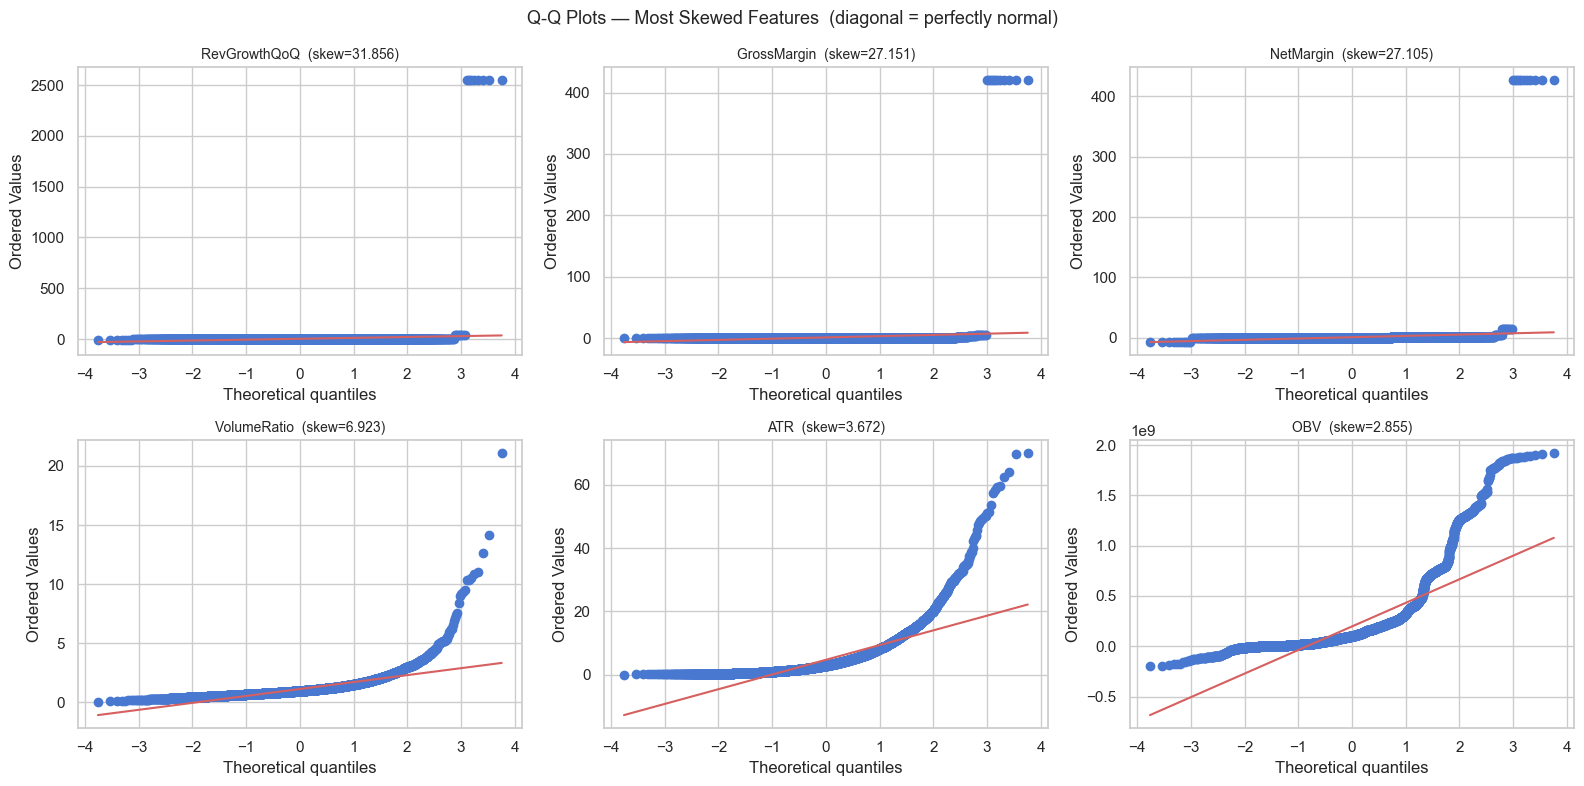

In [4]:
# Q-Q plots for the most skewed features.
# A Q-Q plot compares the quantiles of the observed data against what a normal
# distribution would produce. Points on the diagonal line = normal.
# Curves at the ends = heavy tails or skew.
# We show the 6 most skewed features to visualise the deviation from normality.

most_skewed = norm_df['Skewness'].abs().nlargest(6).index.tolist()
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, feat in enumerate(most_skewed):
    vals = df[feat].dropna().values
    stats.probplot(vals, dist='norm', plot=axes[i])
    axes[i].set_title(f'{feat}  (skew={norm_df.loc[feat,"Skewness"]})', fontsize=10)

plt.suptitle('Q-Q Plots — Most Skewed Features  (diagonal = perfectly normal)', fontsize=13)
plt.tight_layout()
plt.show()

## 2. Feature Importance

Two complementary tests that make different assumptions:

**Mann-Whitney U test** — non-parametric. Asks: *are the rank distributions of a feature different between GapUp=0 and GapUp=1?* No normality assumption. Reports a p-value (statistical significance) and effect size (rank-biserial correlation, −1 to +1).

**Mutual Information** — model-free. Measures how much knowing a feature reduces uncertainty about the target. Captures non-linear relationships that Mann-Whitney misses. A feature with near-zero Pearson correlation but high mutual information is non-linearly predictive — XGBoost and LSTM would exploit this; logistic regression would not.

Together these give a ranking that is valid regardless of the feature's distribution shape.

In [5]:
# Mann-Whitney U test for each feature vs GapUp.
# Null hypothesis: the distributions of the feature in GapUp=0 and GapUp=1 are identical.
# p < 0.05 → statistically significant difference between the two groups.
# Effect size = rank-biserial correlation r = 1 - 2U/(n1*n2).
#   |r| < 0.1 = negligible, 0.1-0.3 = small, 0.3-0.5 = medium, > 0.5 = large.
# Note: statistical significance (p) and practical significance (effect size) are different.
# With ~8,000 rows a tiny difference can be statistically significant but practically useless.

mw_results = []
up   = df[df['GapUp'] == 1]
down = df[df['GapUp'] == 0]

for feat in ALL_FEATURES:
    u_vals = up[feat].dropna().values
    d_vals = down[feat].dropna().values
    if len(u_vals) < 10 or len(d_vals) < 10:
        continue
    stat, p = mannwhitneyu(u_vals, d_vals, alternative='two-sided')
    n1, n2  = len(u_vals), len(d_vals)
    r       = 1 - (2 * stat) / (n1 * n2)   # rank-biserial correlation
    mw_results.append({
        'Feature':     feat,
        'U-statistic': round(stat, 1),
        'p-value':     round(p, 5),
        'Significant': 'Yes' if p < 0.05 else 'No',
        'Effect size r': round(r, 4),
        '|Effect size|': round(abs(r), 4),
    })

mw_df = pd.DataFrame(mw_results).set_index('Feature').sort_values('|Effect size|', ascending=False)
display(mw_df)

,U-statistic,p-value,Significant,Effect size r,|Effect size|
Feature,,,,,
StochPercK,9876482.5,0.00000,Yes,-0.1920,0.1920
RSI,9552258.0,0.00000,Yes,-0.1528,0.1528
ROC,9489076.5,0.00000,Yes,-0.1452,0.1452
MFI,9363666.0,0.00000,Yes,-0.1301,0.1301
CloseVSma20,9079210.0,0.00000,Yes,-0.0958,0.0958
CloseVEma50,8821624.0,0.00000,Yes,-0.0647,0.0647
BollingerBandWidth,7885651.0,0.00016,Yes,0.0483,0.0483
IntraWeekVolatility,7944385.0,0.00129,Yes,0.0412,0.0412
ADX,7986312.0,0.00475,Yes,0.0361,0.0361


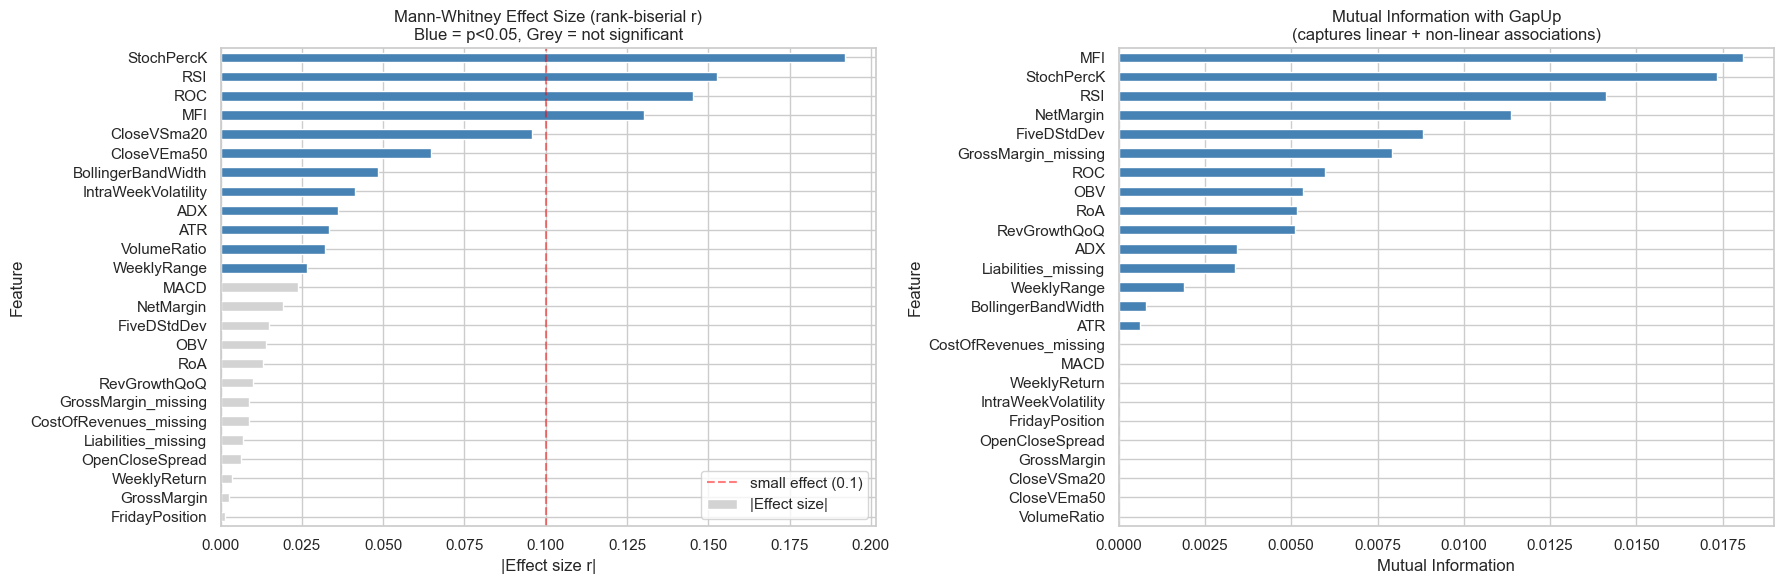

In [6]:
# Mutual information between each feature and GapUp.
# MI = 0 means knowing the feature tells you nothing extra about the target.
# MI > 0 means there is some shared information — linear OR non-linear.
# We use 10 nearest-neighbour estimation (standard for continuous features).
# Random state is fixed so results are reproducible.
# MI values are not directly comparable to p-values — they are a relative ranking.

X_mi = df[ALL_FEATURES].fillna(0).values
y_mi = df['GapUp'].values

mi_scores = mutual_info_classif(X_mi, y_mi, discrete_features=False, random_state=42)
mi_df = pd.DataFrame({'Feature': ALL_FEATURES, 'MutualInfo': mi_scores})
mi_df = mi_df.set_index('Feature').sort_values('MutualInfo', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Effect size (Mann-Whitney)
plot_mw = mw_df['|Effect size|'].sort_values(ascending=True)
colors_mw = ['steelblue' if mw_df.loc[f, 'Significant'] == 'Yes' else 'lightgrey'
             for f in plot_mw.index]
plot_mw.plot(kind='barh', ax=axes[0], color=colors_mw)
axes[0].set_title('Mann-Whitney Effect Size (rank-biserial r)\nBlue = p<0.05, Grey = not significant')
axes[0].set_xlabel('|Effect size r|')
axes[0].axvline(0.1, color='red', linestyle='--', alpha=0.5, label='small effect (0.1)')
axes[0].legend()

# Mutual information
mi_plot = mi_df['MutualInfo'].sort_values(ascending=True)
mi_plot.plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title('Mutual Information with GapUp\n(captures linear + non-linear associations)')
axes[1].set_xlabel('Mutual Information')

plt.tight_layout()
plt.show()

In [7]:
# Combined ranking: average normalised rank from both tests.
# A feature that ranks highly on both tests is robustly important.
# A feature that ranks highly on MI but not Mann-Whitney has a non-linear relationship
# — useful for XGBoost/LSTM but not for logistic regression.
# A feature that ranks highly on Mann-Whitney but not MI has a linear mean-shift.

mw_rank = mw_df['|Effect size|'].rank(ascending=False).rename('MW rank')
mi_rank = mi_df['MutualInfo'].rank(ascending=False).rename('MI rank')

combined = pd.concat([mw_rank, mi_rank], axis=1).dropna()
combined['Avg rank'] = combined.mean(axis=1)
combined = combined.sort_values('Avg rank')
combined['MW effect'] = mw_df['|Effect size|'].round(4)
combined['MI score']  = mi_df['MutualInfo'].round(5)
combined['MW sig']    = mw_df['Significant']

print('Feature importance — combined ranking (lower avg rank = more important):')
display(combined)

Feature importance — combined ranking (lower avg rank = more important):


,MW rank,MI rank,Avg rank,MW effect,MI score,MW sig
Feature,,,,,,
StochPercK,1.0,2.0,1.50,0.1920,0.01732,Yes
RSI,2.0,3.0,2.50,0.1528,0.01411,Yes
MFI,4.0,1.0,2.50,0.1301,0.01808,Yes
ROC,3.0,7.0,5.00,0.1452,0.00597,Yes
NetMargin,14.0,4.0,9.00,0.0192,0.01136,No
FiveDStdDev,15.0,5.0,10.00,0.0150,0.00883,No
ADX,9.0,11.0,10.00,0.0361,0.00343,Yes
BollingerBandWidth,7.0,14.0,10.50,0.0483,0.00079,Yes
OBV,16.0,8.0,12.00,0.0140,0.00534,No


## 3. Variance Inflation Factor (VIF)

VIF measures how much a feature's variance is inflated by its linear relationship with *all other features*. It is a more complete measure of multicollinearity than pairwise correlation because it captures group redundancy.

**VIF = 1** — no collinearity with other features  
**VIF 1–5** — moderate, generally acceptable  
**VIF 5–10** — high collinearity, coefficients become unstable in logistic regression  
**VIF > 10** — severe; logistic regression cannot reliably estimate the coefficient

Features with VIF > 10 should be removed *before* fitting logistic regression. XGBoost and LSTM are not sensitive to VIF.

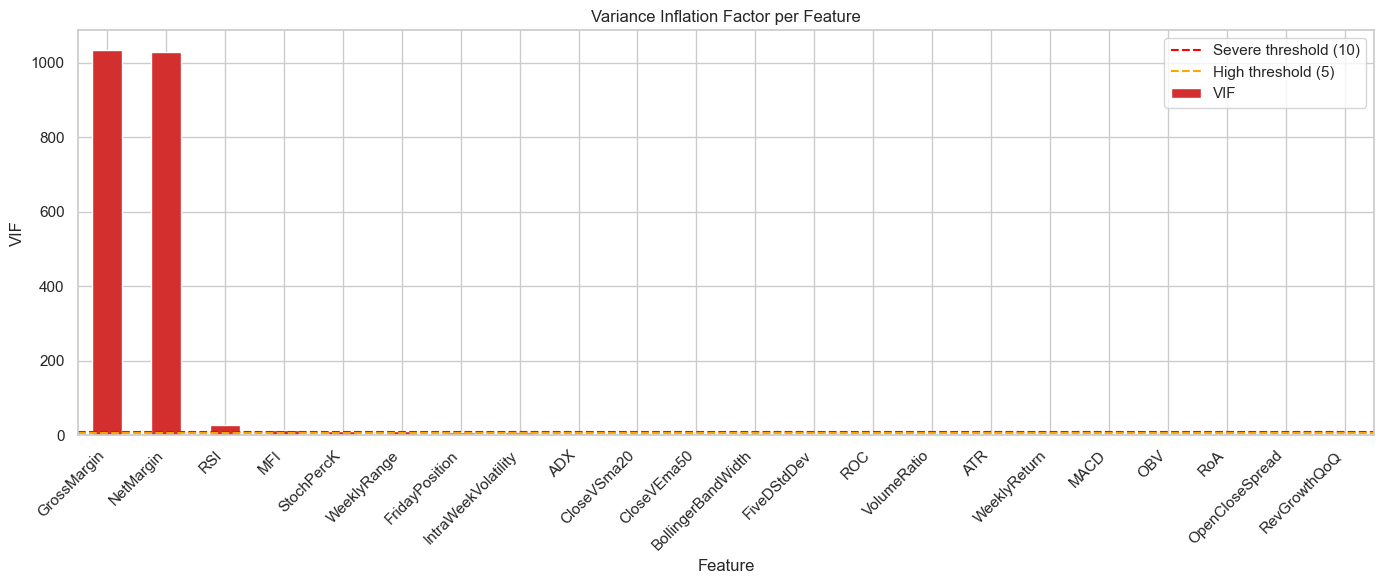

,VIF,Severity
Feature,,
GrossMargin,1035.292296,SEVERE (drop for LogReg)
NetMargin,1030.178593,SEVERE (drop for LogReg)
RSI,27.302875,SEVERE (drop for LogReg)
MFI,13.990142,SEVERE (drop for LogReg)
StochPercK,11.257354,SEVERE (drop for LogReg)
WeeklyRange,10.914303,SEVERE (drop for LogReg)
FridayPosition,9.204822,High
IntraWeekVolatility,8.518389,High
ADX,6.705032,High



Features with VIF > 10 (remove before Logistic Regression): ['GrossMargin', 'NetMargin', 'RSI', 'MFI', 'StochPercK', 'WeeklyRange']


In [8]:
# Compute VIF for all continuous features (excluding binary missingness indicators
# since VIF is not meaningful for binary columns).
# VIF for feature j = 1 / (1 - R²_j) where R²_j is the R-squared from regressing
# feature j on all other features.
# We drop rows with any NaN first since VIF requires a complete matrix.

continuous_features = TECHNICAL + PRICE_AGG + FUNDAMENTAL
X_vif = df[continuous_features].dropna()

vif_data = pd.DataFrame()
vif_data['Feature'] = continuous_features
vif_data['VIF'] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]
vif_data = vif_data.set_index('Feature').sort_values('VIF', ascending=False)
vif_data['Severity'] = vif_data['VIF'].apply(
    lambda v: 'SEVERE (drop for LogReg)' if v > 10
              else ('High' if v > 5 else ('Moderate' if v > 2 else 'Low'))
)

fig, ax = plt.subplots(figsize=(14, 6))
colors = ['#d32f2f' if v > 10 else '#f57c00' if v > 5 else '#388e3c'
          for v in vif_data['VIF']]
vif_data['VIF'].plot(kind='bar', ax=ax, color=colors)
ax.axhline(10, color='red',    linestyle='--', label='Severe threshold (10)')
ax.axhline(5,  color='orange', linestyle='--', label='High threshold (5)')
ax.set_title('Variance Inflation Factor per Feature')
ax.set_ylabel('VIF')
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

display(vif_data)
severe = vif_data[vif_data['VIF'] > 10].index.tolist()
print(f'\nFeatures with VIF > 10 (remove before Logistic Regression): {severe}')

In [9]:
# Iterative VIF pruning for Logistic Regression feature set.
# We repeatedly remove the feature with the highest VIF until all VIF < 10.
# This gives the recommended feature set for logistic regression.
# XGBoost uses all 25 features (not sensitive to VIF).

logreg_features = continuous_features.copy()
dropped_vif = []

while True:
    X_iter = df[logreg_features].dropna()
    vifs = [variance_inflation_factor(X_iter.values, i) for i in range(X_iter.shape[1])]
    max_vif = max(vifs)
    if max_vif <= 10:
        break
    drop_feat = logreg_features[vifs.index(max_vif)]
    print(f'Dropping {drop_feat} (VIF={max_vif:.1f})')
    dropped_vif.append(drop_feat)
    logreg_features.remove(drop_feat)

# Add missingness indicators back (binary, not subject to VIF pruning)
logreg_features_final = logreg_features + MISS_IND

print(f'\nLogistic Regression feature set after VIF pruning ({len(logreg_features_final)} features):')
print(logreg_features_final)
print(f'\nDropped due to high VIF: {dropped_vif}')

Dropping GrossMargin (VIF=1035.3)
Dropping RSI (VIF=27.3)


Dropping WeeklyRange (VIF=10.9)

Logistic Regression feature set after VIF pruning (22 features):
['MACD', 'ROC', 'StochPercK', 'CloseVEma50', 'CloseVSma20', 'ADX', 'BollingerBandWidth', 'ATR', 'FiveDStdDev', 'OBV', 'MFI', 'VolumeRatio', 'WeeklyReturn', 'IntraWeekVolatility', 'FridayPosition', 'OpenCloseSpread', 'NetMargin', 'RoA', 'RevGrowthQoQ', 'GrossMargin_missing', 'CostOfRevenues_missing', 'Liabilities_missing']

Dropped due to high VIF: ['GrossMargin', 'RSI', 'WeeklyRange']


## 4. Stationarity (Augmented Dickey-Fuller Test)

A time series is **stationary** if its mean, variance, and autocorrelation are constant over time. Non-stationary features drift — the value of RSI in 2016 might have a systematically different distribution than RSI in 2023. This causes:
- Model coefficients estimated on early data to become wrong on later data
- Walk-forward validation results to be unreliable across long windows

**ADF test null hypothesis:** the series has a unit root (non-stationary).  
**p < 0.05** → reject null → series is stationary.  
**p ≥ 0.05** → cannot reject non-stationarity → feature may need first-differencing.

We run the test per ticker and report the fraction of tickers where the feature is stationary. A feature that is non-stationary in most tickers is a concern.

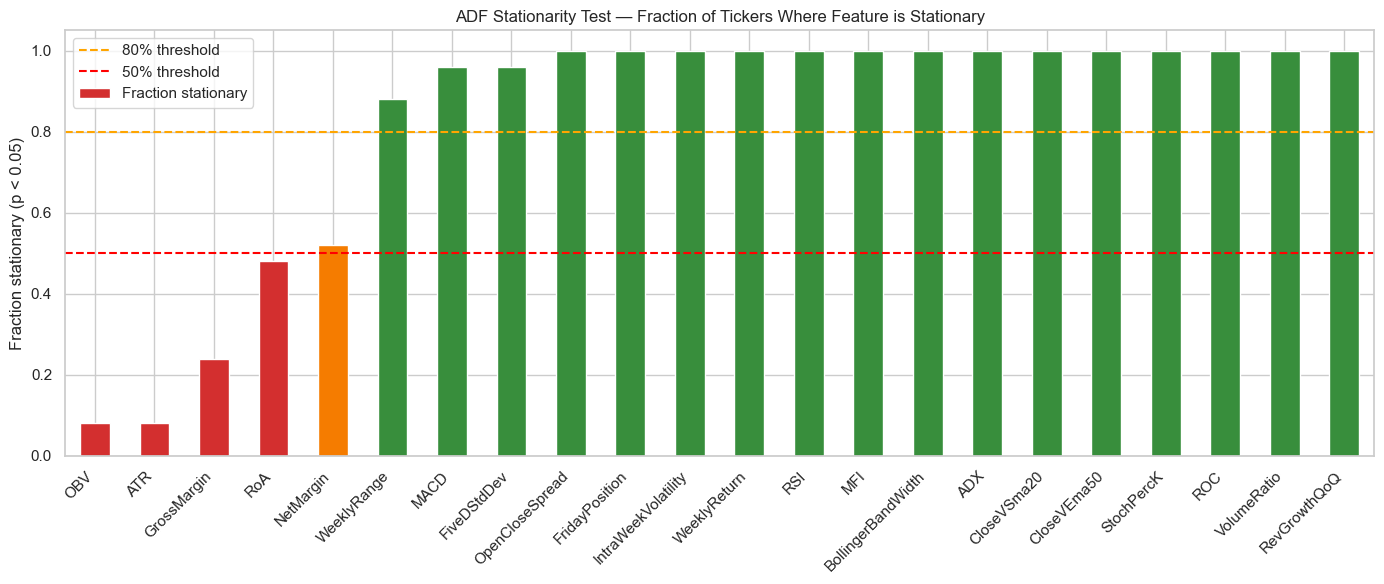

,Stationary tickers,Total tickers,Fraction stationary
OBV,2.0,25.0,0.08
ATR,2.0,25.0,0.08
GrossMargin,6.0,25.0,0.24
RoA,12.0,25.0,0.48
NetMargin,13.0,25.0,0.52
WeeklyRange,22.0,25.0,0.88
MACD,24.0,25.0,0.96
FiveDStdDev,24.0,25.0,0.96
OpenCloseSpread,25.0,25.0,1.00
FridayPosition,25.0,25.0,1.00



Features non-stationary in majority of tickers: ['OBV', 'ATR', 'GrossMargin', 'RoA']
→ These features may behave differently across time periods.
  Walk-forward validation is critical to prevent the model from over-fitting to one era.


In [10]:
# ADF test run per ticker per feature.
# We test per ticker (not on the full pooled series) because pooling 25 tickers
# would mix different price scales and regimes, which could mask or exaggerate
# non-stationarity.
# For each feature we report: what fraction of tickers showed stationary series.
# maxlag=None lets the ADF choose the lag order automatically (AIC criterion).

adf_results = {}

for feat in TECHNICAL + PRICE_AGG + FUNDAMENTAL:
    stationary_count = 0
    ticker_count     = 0
    for ticker in df['Ticker'].unique():
        series = df[df['Ticker'] == ticker][feat].dropna()
        if len(series) < 20:
            continue
        try:
            result = adfuller(series, autolag='AIC')
            p_val  = result[1]
            if p_val < 0.05:
                stationary_count += 1
        except Exception:
            pass
        ticker_count += 1
    adf_results[feat] = {
        'Stationary tickers': stationary_count,
        'Total tickers':      ticker_count,
        'Fraction stationary': round(stationary_count / ticker_count, 3) if ticker_count else np.nan
    }

adf_df = pd.DataFrame(adf_results).T.sort_values('Fraction stationary')

fig, ax = plt.subplots(figsize=(14, 6))
colors = ['#d32f2f' if v < 0.5 else '#f57c00' if v < 0.8 else '#388e3c'
          for v in adf_df['Fraction stationary']]
adf_df['Fraction stationary'].plot(kind='bar', ax=ax, color=colors)
ax.axhline(0.8, color='orange', linestyle='--', label='80% threshold')
ax.axhline(0.5, color='red',    linestyle='--', label='50% threshold')
ax.set_title('ADF Stationarity Test — Fraction of Tickers Where Feature is Stationary')
ax.set_ylabel('Fraction stationary (p < 0.05)')
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

display(adf_df)
non_stationary = adf_df[adf_df['Fraction stationary'] < 0.5].index.tolist()
print(f'\nFeatures non-stationary in majority of tickers: {non_stationary}')
print('→ These features may behave differently across time periods.')
print('  Walk-forward validation is critical to prevent the model from over-fitting to one era.')

## 5. Scaling Analysis & Preprocessing Recommendations

Logistic regression and LSTM are both sensitive to feature scale — a feature with values in the billions (OBV) will dominate gradient updates over a feature bounded between 0 and 100 (RSI) unless scaled. XGBoost is scale-invariant (splits are relative).

Two scaling decisions:
1. **Log-transform first** — for features with extreme positive skew and heavy right tails (e.g. OBV, Volume). Compresses the range before scaling.
2. **StandardScaler** (zero mean, unit variance) — standard choice after log-transform for logistic regression and LSTM.

In [11]:
# Scale and range analysis for all continuous features.
# We report the raw min, max, mean, std, and skewness.
# Features with |skewness| > 2 and range spanning many orders of magnitude
# are candidates for log-transform before StandardScaler.
# OBV is in cumulative volume units (can be billions) and is
# not comparable across tickers — it needs per-ticker z-scoring.

scale_stats = df[continuous_features].describe().T
scale_stats['skewness'] = df[continuous_features].skew().round(3)
scale_stats['range']    = scale_stats['max'] - scale_stats['min']
scale_stats = scale_stats[['min','max','range','mean','std','skewness']].round(4)
scale_stats = scale_stats.sort_values('skewness', key=abs, ascending=False)

display(scale_stats)

,min,max,range,mean,std,skewness
RevGrowthQoQ,-4.839900e+00,2.546667e+03,2.551506e+03,2.565900e+00,7.978180e+01,31.856
GrossMargin,-2.300000e-01,4.198330e+02,4.200630e+02,1.301600e+00,1.539340e+01,27.151
NetMargin,-6.683000e+00,4.263330e+02,4.330160e+02,7.401000e-01,1.566220e+01,27.105
VolumeRatio,7.780000e-02,2.105810e+01,2.098030e+01,1.136000e+00,7.536000e-01,6.923
ATR,8.840000e-02,6.987600e+01,6.978760e+01,4.738500e+00,5.678900e+00,3.672
OBV,-1.961754e+08,1.916492e+09,2.112667e+09,1.965154e+08,2.868510e+08,2.855
FiveDStdDev,6.000000e-04,1.661000e-01,1.655000e-01,1.670000e-02,1.130000e-02,2.565
MACD,-6.652690e+01,9.302390e+01,1.595508e+02,8.222000e-01,5.506100e+00,2.399
IntraWeekVolatility,9.000000e-04,1.535000e-01,1.526000e-01,1.630000e-02,1.110000e-02,2.333
WeeklyRange,1.140000e-02,4.505000e-01,4.392000e-01,6.050000e-02,3.440000e-02,2.153


In [12]:
# Preprocessing decision summary.
# Based on scale analysis and skewness we decide per feature:
#   'log1p + StandardScaler' for heavy right-skewed positive features
#   'per-ticker z-score' for OBV which is cumulative and not cross-ticker comparable
#   'StandardScaler' for everything else
#   'none' for binary missingness indicators

def recommend_scaling(feat, skew_val, min_val):
    if feat in MISS_IND:
        return 'none (binary)'
    if feat == 'OBV':
        return 'per-ticker z-score'
    if abs(skew_val) > 2 and min_val >= 0:
        return 'log1p → StandardScaler'
    return 'StandardScaler'

scale_recs = []
for feat in ALL_FEATURES:
    skew = df[feat].skew() if feat not in MISS_IND else 0
    minv = df[feat].min()  if feat not in MISS_IND else 0
    scale_recs.append({
        'Feature':    feat,
        'Skewness':   round(skew, 3),
        'Min':        round(minv, 3),
        'Scaling':    recommend_scaling(feat, skew, minv)
    })

scale_rec_df = pd.DataFrame(scale_recs).set_index('Feature')
print('Preprocessing recommendations per feature:')
display(scale_rec_df)
print()
print('Note: XGBoost does not require any scaling — applies to LogReg and LSTM only.')

Preprocessing recommendations per feature:


,Skewness,Min,Scaling
Feature,,,
RSI,-0.167,0.000000e+00,StandardScaler
MACD,2.399,-6.652700e+01,StandardScaler
ROC,-0.114,-2.580000e-01,StandardScaler
StochPercK,-0.096,0.000000e+00,StandardScaler
CloseVEma50,-0.278,-2.520000e-01,StandardScaler
CloseVSma20,-0.296,-2.380000e-01,StandardScaler
ADX,0.206,3.952000e+00,StandardScaler
BollingerBandWidth,1.740,8.000000e-03,StandardScaler
ATR,3.672,8.800000e-02,log1p → StandardScaler



Note: XGBoost does not require any scaling — applies to LogReg and LSTM only.


## 6. Principal Component Analysis (PCA)

PCA projects the features into a new orthogonal space ordered by variance explained. It answers two questions:
1. **How redundant is the feature set?** If 5 components explain 90% of variance, the 22 features are highly redundant.
2. **Is PCA-reduced modelling worth trying?** The proposal calls for PCA variants of all three models. This section justifies that decision.

We run PCA on the continuous features only (excluding binary missingness indicators), after StandardScaling.

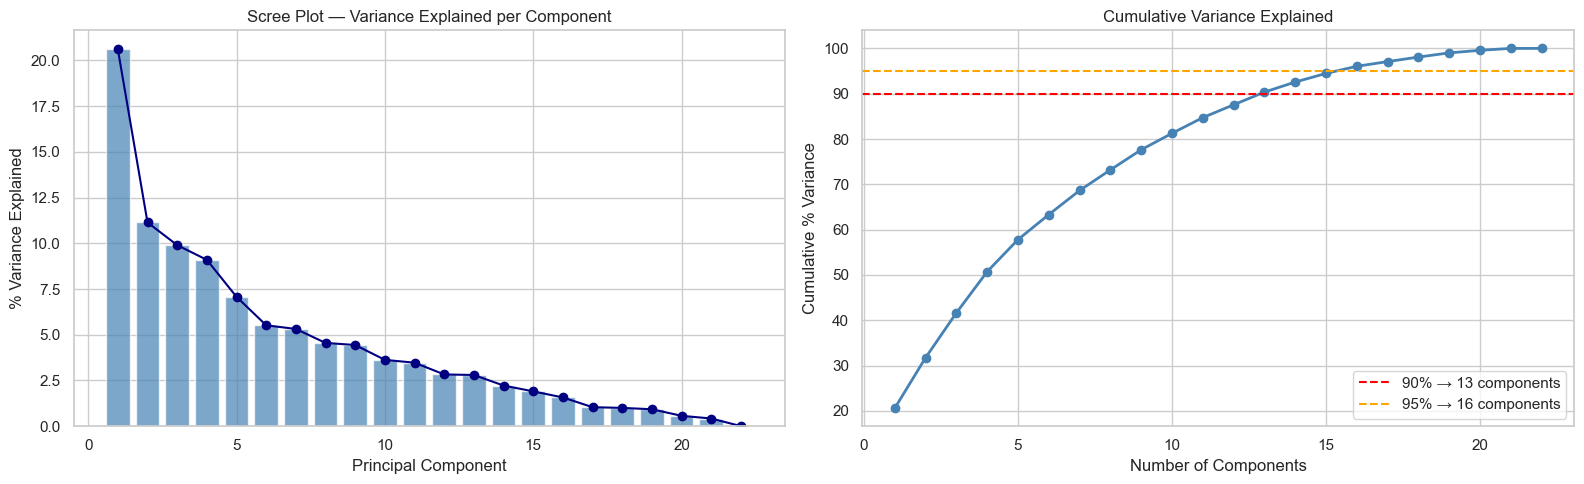

Components needed to explain 90% of variance: 13
Components needed to explain 95% of variance: 16
Total original features: 22
Reduction ratio (90%): 22/13 = 1.7x


In [13]:
# PCA on continuous features after StandardScaling.
# StandardScaler is applied first because PCA is variance-based — features with
# larger raw scale (e.g. OBV in billions vs RSI in 0-100) would otherwise dominate
# the principal components regardless of their actual information content.
# We use per-ticker z-scoring for OBV before entering it into PCA.

X_pca_df = df[continuous_features].dropna().copy()

# Per-ticker z-score OBV
X_pca_df['OBV'] = (
    X_pca_df['OBV']
    .groupby(df.loc[X_pca_df.index, 'Ticker'])
    .transform(lambda x: (x - x.mean()) / (x.std() + 1e-8))
)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_pca_df)

pca = PCA(n_components=len(continuous_features))
pca.fit(X_scaled)

explained        = pca.explained_variance_ratio_
cumulative_var   = np.cumsum(explained)
n_90             = np.argmax(cumulative_var >= 0.90) + 1
n_95             = np.argmax(cumulative_var >= 0.95) + 1

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Scree plot — variance explained per component
axes[0].bar(range(1, len(explained)+1), explained*100, color='steelblue', alpha=0.7)
axes[0].plot(range(1, len(explained)+1), explained*100, 'o-', color='navy', linewidth=1.5)
axes[0].set_title('Scree Plot — Variance Explained per Component')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('% Variance Explained')

# Cumulative variance plot
axes[1].plot(range(1, len(cumulative_var)+1), cumulative_var*100, 'o-', color='steelblue', linewidth=2)
axes[1].axhline(90, color='red',    linestyle='--', label=f'90% → {n_90} components')
axes[1].axhline(95, color='orange', linestyle='--', label=f'95% → {n_95} components')
axes[1].set_title('Cumulative Variance Explained')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative % Variance')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'Components needed to explain 90% of variance: {n_90}')
print(f'Components needed to explain 95% of variance: {n_95}')
print(f'Total original features: {len(continuous_features)}')
print(f'Reduction ratio (90%): {len(continuous_features)}/{n_90} = {len(continuous_features)/n_90:.1f}x')

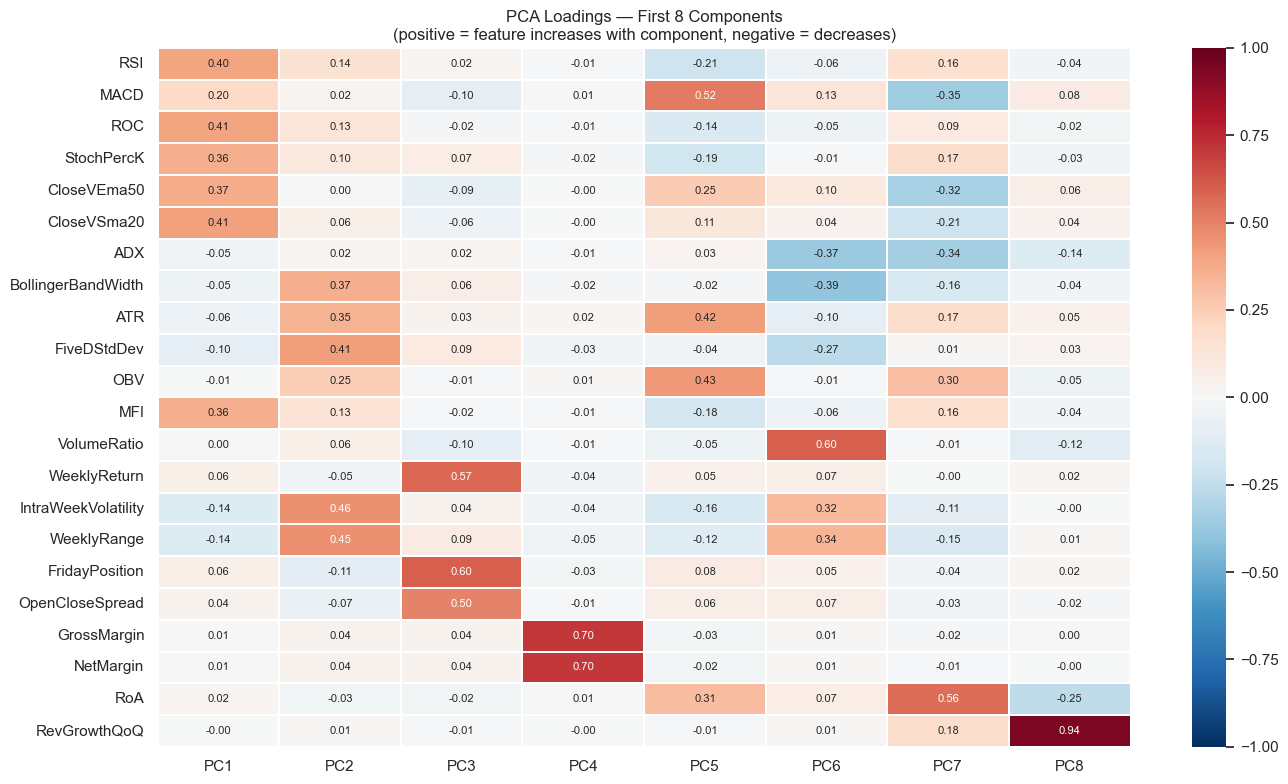

In [14]:
# PCA loadings heatmap — which original features contribute most to each component?
# Each cell shows how strongly the original feature loads onto that component.
# Components that load heavily on a cluster of similar features (e.g. ATR, Bollinger, FiveDStdDev)
# confirm those features are measuring the same underlying signal — PCA is collapsing them.
# We show only the first 8 components for readability.

n_show   = min(8, len(continuous_features))
loadings = pd.DataFrame(
    pca.components_[:n_show].T,
    index=continuous_features,
    columns=[f'PC{i+1}' for i in range(n_show)]
)

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(loadings, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax, linewidths=0.3, annot_kws={'size': 8})
ax.set_title(f'PCA Loadings — First {n_show} Components\n(positive = feature increases with component, negative = decreases)')
plt.tight_layout()
plt.show()

## 7. Autocorrelation of the Target (ACF/PACF)

This section directly motivates (or challenges) the use of LSTM.

**ACF (Autocorrelation Function):** correlation between GapUp at time *t* and GapUp at time *t−k* for lag *k*. If ACF is near zero for all lags, knowing last week's gap direction tells you nothing about this week's.

**PACF (Partial Autocorrelation Function):** correlation at lag *k* after removing the effect of all shorter lags. A spike at lag 2 in PACF but not in ACF would mean "two weeks ago matters, but only because last week correlated with it."

If both ACF and PACF are near zero for all lags, the target is essentially a random sequence — LSTM's sequential modelling provides no advantage over a static classifier.

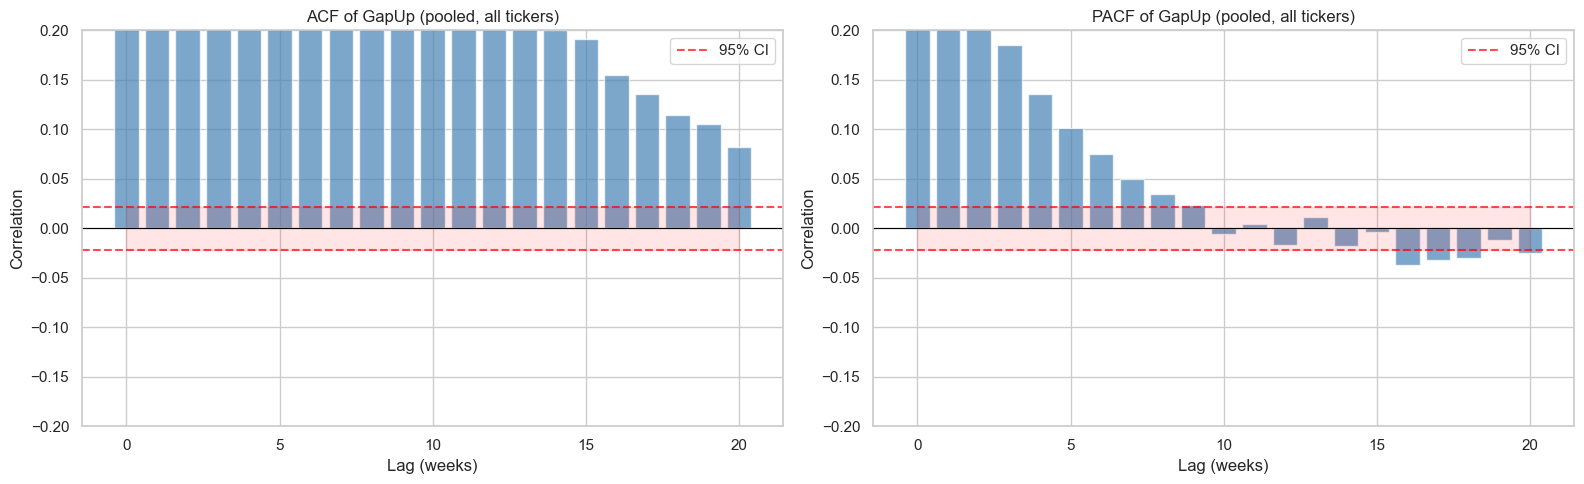

In [15]:
# ACF and PACF of GapUp, computed on the pooled series (all tickers, sorted by date).
# The blue shaded region is the 95% confidence band (±1.96/sqrt(N)).
# Bars outside the band indicate statistically significant autocorrelation at that lag.
# We also run the test per-ticker and report how many tickers show any significant lag.

# Pooled series (sorted by date, all tickers)
pooled = df.sort_values('Date')['GapUp'].values
n_lags = 20

acf_vals  = acf(pooled,  nlags=n_lags, alpha=0.05)
pacf_vals = pacf(pooled, nlags=n_lags, alpha=0.05)

acf_coefs,  (acf_lower,  acf_upper)  = acf_vals[0],  acf_vals[1].T
pacf_coefs, (pacf_lower, pacf_upper) = pacf_vals[0], pacf_vals[1].T

lags = np.arange(n_lags + 1)
conf_bound = 1.96 / np.sqrt(len(pooled))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, coefs, title in [
    (axes[0], acf_coefs,  'ACF of GapUp (pooled, all tickers)'),
    (axes[1], pacf_coefs, 'PACF of GapUp (pooled, all tickers)')
]:
    ax.bar(lags, coefs, color='steelblue', alpha=0.7)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.axhline( conf_bound, color='red', linestyle='--', alpha=0.7, label='95% CI')
    ax.axhline(-conf_bound, color='red', linestyle='--', alpha=0.7)
    ax.fill_between(lags, -conf_bound, conf_bound, alpha=0.1, color='red')
    ax.set_title(title)
    ax.set_xlabel('Lag (weeks)')
    ax.set_ylabel('Correlation')
    ax.set_ylim(-0.2, 0.2)
    ax.legend()

plt.tight_layout()
plt.show()

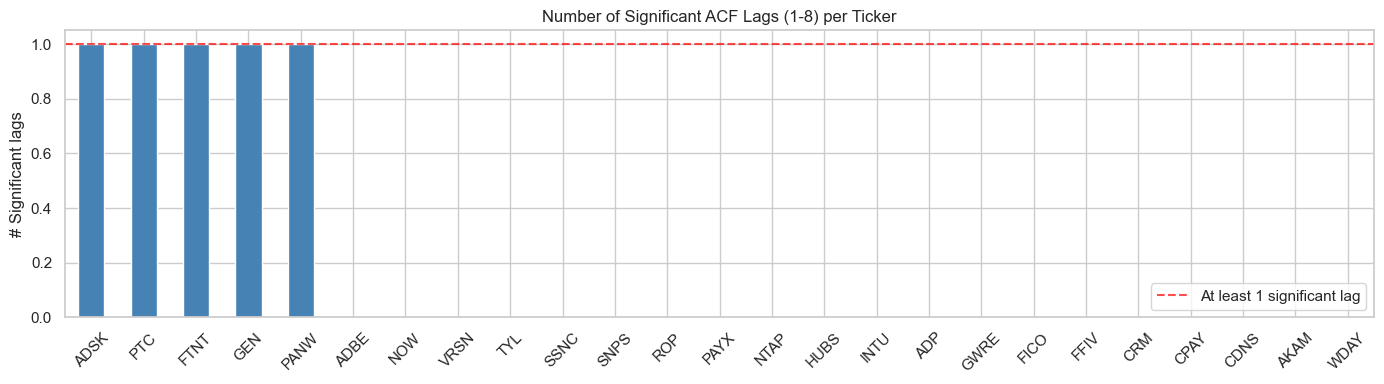

Tickers with >= 1 significant autocorrelation lag: 5 / 25

LSTM motivation: WEAK — most tickers show no sequential structure in the target.
LSTM may still add value through sequential feature patterns, not target autocorrelation.


In [16]:
# Per-ticker ACF — how many tickers show significant autocorrelation at any lag?
# If the pooled ACF is flat but some individual tickers show structure,
# pooling may have cancelled out real ticker-level patterns.
# We check lags 1-8 (2 months of weekly data).

sig_lag_count = {}
for ticker in df['Ticker'].unique():
    series = df[df['Ticker'] == ticker].sort_values('Date')['GapUp'].values
    if len(series) < 30:
        continue
    acf_t = acf(series, nlags=8, alpha=0.05)
    acf_c = acf_t[0][1:]   # skip lag-0 (always 1)
    bound = 1.96 / np.sqrt(len(series))
    n_sig = (np.abs(acf_c) > bound).sum()
    sig_lag_count[ticker] = n_sig

sig_df = pd.Series(sig_lag_count).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 4))
sig_df.plot(kind='bar', ax=ax, color='steelblue')
ax.axhline(1, color='red', linestyle='--', alpha=0.7, label='At least 1 significant lag')
ax.set_title('Number of Significant ACF Lags (1-8) per Ticker')
ax.set_ylabel('# Significant lags')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

tickers_with_sig = (sig_df >= 1).sum()
print(f'Tickers with >= 1 significant autocorrelation lag: {tickers_with_sig} / {len(sig_df)}')
print()
if tickers_with_sig / len(sig_df) < 0.3:
    print('LSTM motivation: WEAK — most tickers show no sequential structure in the target.')
    print('LSTM may still add value through sequential feature patterns, not target autocorrelation.')
else:
    print('LSTM motivation: SUPPORTED — sequential structure present in the target for many tickers.')

## 8. Summary of Findings & Modelling Decisions

In [17]:
# Final consolidated decision table for the modelling notebook.
print('=' * 70)
print('STATISTICAL ANALYSIS SUMMARY')
print('=' * 70)

n_non_normal = (norm_df['Normal?'] == 'No').sum()
print(f'\n1. NORMALITY')
print(f'   {n_non_normal}/{len(norm_df)} features are non-normal (Shapiro-Wilk p < 0.05)')
print(f'   → Use Mann-Whitney U (not t-test) for all class comparison tests')
print(f'   → Apply log1p transform before StandardScaler for heavily skewed features')

print(f'\n2. FEATURE IMPORTANCE (top 5 by combined rank)')
for feat in combined.index[:5]:
    print(f'   {feat:25s}  MW_r={combined.loc[feat,"MW effect"]:.4f}  MI={combined.loc[feat,"MI score"]:.5f}  sig={combined.loc[feat,"MW sig"]}')

print(f'\n3. MULTICOLLINEARITY (VIF)')
print(f'   Features with VIF > 10 (drop for LogReg): {severe}')
print(f'   LogReg feature set after pruning: {len(logreg_features_final)} features')
print(f'   XGBoost: use all {len(ALL_FEATURES)} features (not sensitive to VIF)')

non_stat = adf_df[adf_df['Fraction stationary'] < 0.5].index.tolist()
print(f'\n4. STATIONARITY (ADF)')
print(f'   Non-stationary in majority of tickers: {non_stat}')
print(f'   → Walk-forward validation is critical (do not use random split)')

print(f'\n5. DIMENSIONALITY (PCA)')
print(f'   Components for 90% variance: {n_90} of {len(continuous_features)}')
print(f'   Components for 95% variance: {n_95} of {len(continuous_features)}')
print(f'   → PCA-reduced variants are worth testing (meaningful compression exists)')

tickers_with_sig = (sig_df >= 1).sum()
print(f'\n6. TARGET AUTOCORRELATION (ACF/PACF)')
print(f'   Tickers with >= 1 significant lag: {tickers_with_sig}/{len(sig_df)}')
print(f'   → LSTM justified primarily by sequential feature patterns, not target ACF')

print(f'\n7. FEATURE SETS FOR MODELLING')
print(f'   Logistic Regression : {len(logreg_features_final)} features (VIF-pruned + missingness indicators)')
print(f'   XGBoost             : {len(ALL_FEATURES)} features (all, no VIF pruning needed)')
print(f'   LSTM                : {len(LSTM_FEATURES)} features (technical + price agg only; no fundamentals)')
print(f'   All models also get a PCA-reduced variant for comparison.')

print(f'\n8. PREPROCESSING PIPELINE (LogReg + LSTM only, not XGBoost)')
log1p_feats = scale_rec_df[scale_rec_df['Scaling'] == 'log1p → StandardScaler'].index.tolist()
zticker_feats = scale_rec_df[scale_rec_df['Scaling'] == 'per-ticker z-score'].index.tolist()
print(f'   log1p → StandardScaler : {log1p_feats}')
print(f'   Per-ticker z-score     : {zticker_feats}')
print(f'   StandardScaler only    : all remaining continuous features')
print(f'   No scaling             : {MISS_IND} (binary)')
print('=' * 70)

STATISTICAL ANALYSIS SUMMARY

1. NORMALITY
   25/25 features are non-normal (Shapiro-Wilk p < 0.05)
   → Use Mann-Whitney U (not t-test) for all class comparison tests
   → Apply log1p transform before StandardScaler for heavily skewed features

2. FEATURE IMPORTANCE (top 5 by combined rank)
   StochPercK                 MW_r=0.1920  MI=0.01732  sig=Yes
   RSI                        MW_r=0.1528  MI=0.01411  sig=Yes
   MFI                        MW_r=0.1301  MI=0.01808  sig=Yes
   ROC                        MW_r=0.1452  MI=0.00597  sig=Yes
   NetMargin                  MW_r=0.0192  MI=0.01136  sig=No

3. MULTICOLLINEARITY (VIF)
   Features with VIF > 10 (drop for LogReg): ['GrossMargin', 'NetMargin', 'RSI', 'MFI', 'StochPercK', 'WeeklyRange']
   LogReg feature set after pruning: 22 features
   XGBoost: use all 25 features (not sensitive to VIF)

4. STATIONARITY (ADF)
   Non-stationary in majority of tickers: ['OBV', 'ATR', 'GrossMargin', 'RoA']
   → Walk-forward validation is critical (